In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests #librería utilizada para abrir archivos desde la web
import seaborn as sns

Primero abrimos el conjunto de datos, usando el link de los datos públicos del portal 
de las ecobicis https://ecobici.cdmx.gob.mx/datos-abiertos/

In [2]:
r1=r"https://ecobici.cdmx.gob.mx/wp-content/uploads/2026/10/public_data_web_2026-09.csv"
df=pd.read_csv(r1)


Realizamos el análisis exploratorio de nuestro conjunto de datos

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1498934 entries, 0 to 1498933
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Genero_Usuario         1498934 non-null  str    
 1   Edad_Usuario           1498905 non-null  float64
 2   Bici                   1498934 non-null  int64  
 3   Ciclo_Estacion_Retiro  1498934 non-null  str    
 4   Fecha_Retiro           1498934 non-null  str    
 5   Hora_Retiro            1498934 non-null  str    
 6   Ciclo_EstacionArribo   1498934 non-null  str    
 7   Fecha_Arribo           1498934 non-null  str    
 8   Hora_Arribo            1498934 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 102.9 MB


In [9]:
df.shape

(1498934, 9)

Salvo la edad del usuario, todas las columnas coinciden en dimensión, por lo que se eliminan los datos daltantes al representar menos del 1 % de todo el conjunto. Por otro lado, la mayor parte de las columnas son de tipo str

In [10]:
df.isnull().sum()

Genero_Usuario            0
Edad_Usuario             29
Bici                      0
Ciclo_Estacion_Retiro     0
Fecha_Retiro              0
Hora_Retiro               0
Ciclo_EstacionArribo      0
Fecha_Arribo              0
Hora_Arribo               0
dtype: int64

In [64]:
DD=df.dropna()

In [12]:
DD.info()

<class 'pandas.DataFrame'>
Index: 1498905 entries, 0 to 1498933
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Genero_Usuario         1498905 non-null  str    
 1   Edad_Usuario           1498905 non-null  float64
 2   Bici                   1498905 non-null  int64  
 3   Ciclo_Estacion_Retiro  1498905 non-null  str    
 4   Fecha_Retiro           1498905 non-null  str    
 5   Hora_Retiro            1498905 non-null  str    
 6   Ciclo_EstacionArribo   1498905 non-null  str    
 7   Fecha_Arribo           1498905 non-null  str    
 8   Hora_Arribo            1498905 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 114.4 MB


In [13]:
DD.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo
0,M,30.0,6583322,028,31/08/2026,23:54:59,258,01/09/2026,00:00:03
1,F,33.0,4139655,030,31/08/2026,23:24:43,530,01/09/2026,00:00:04
2,O,32.0,6378079,139,31/08/2026,23:46:59,559,01/09/2026,00:00:35
3,M,35.0,6074272,365,31/08/2026,23:52:10,312,01/09/2026,00:00:44
4,M,30.0,4162376,412,31/08/2026,23:51:45,337,01/09/2026,00:00:55


Realizamos una limpieza general de los datos, procurando que se pueda realizar estadística con las columnas
numéricas, como la edad, el género, fechas y horas.

In [65]:

DD["Edad_Usuario"]=DD["Edad_Usuario"].astype(int)

In [18]:
DD["Genero_Usuario"].unique()
DD["Genero_Usuario"].value_counts()

Genero_Usuario
M    1016833
F     416335
?      38763
O      26974
Name: count, dtype: int64

Text(0, 0.5, 'Cuentas')

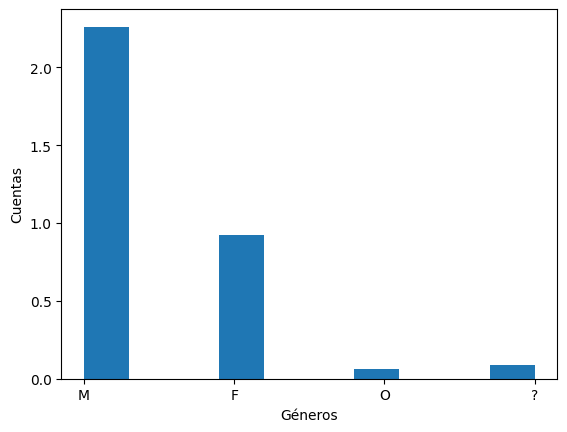

In [21]:
plt.hist(DD['Genero_Usuario'],density=True,)
plt.xlabel('Géneros')
plt.ylabel("Cuentas")


Text(0, 0.5, 'Cuentas')

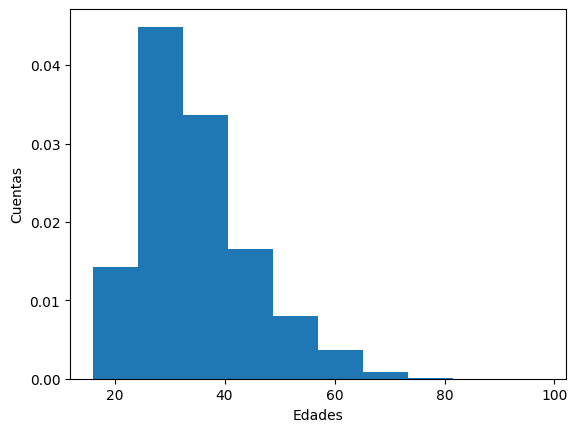

In [38]:
plt.hist(DD["Edad_Usuario"],density=True,)
plt.xlabel('Edades')
plt.ylabel("Cuentas")

In [45]:
DD.info()

<class 'pandas.DataFrame'>
Index: 1498905 entries, 0 to 1498933
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype
---  ------                 --------------    -----
 0   Genero_Usuario         1498905 non-null  str  
 1   Edad_Usuario           1498905 non-null  int64
 2   Bici                   1498905 non-null  int64
 3   Ciclo_Estacion_Retiro  1498905 non-null  str  
 4   Fecha_Retiro           1498905 non-null  str  
 5   Hora_Retiro            1498905 non-null  str  
 6   Ciclo_EstacionArribo   1498905 non-null  str  
 7   Fecha_Arribo           1498905 non-null  str  
 8   Hora_Arribo            1498905 non-null  str  
dtypes: int64(2), str(7)
memory usage: 114.4 MB


In [66]:
from datetime import datetime
#Fechas 
DD["Fecha_Retiro"]=DD["Fecha_Retiro"].apply(lambda x: datetime.strptime(x,"%d/%m/%Y"))
DD["Fecha_Arribo"]=DD["Fecha_Arribo"].apply(lambda x: datetime.strptime(x,"%d/%m/%Y"))
#Horas
DD["Hora_Retiro"]=DD["Hora_Retiro"].apply(lambda x: datetime.strptime(x,"%H:%M:%S"))
DD["Hora_Arribo"]=DD["Hora_Arribo"].apply(lambda x: datetime.strptime(x,"%H:%M:%S"))

In [67]:
DD.info()

<class 'pandas.DataFrame'>
Index: 1498905 entries, 0 to 1498933
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Genero_Usuario         1498905 non-null  str           
 1   Edad_Usuario           1498905 non-null  int64         
 2   Bici                   1498905 non-null  int64         
 3   Ciclo_Estacion_Retiro  1498905 non-null  str           
 4   Fecha_Retiro           1498905 non-null  datetime64[us]
 5   Hora_Retiro            1498905 non-null  datetime64[us]
 6   Ciclo_EstacionArribo   1498905 non-null  str           
 7   Fecha_Arribo           1498905 non-null  datetime64[us]
 8   Hora_Arribo            1498905 non-null  datetime64[us]
dtypes: datetime64[us](4), int64(2), str(3)
memory usage: 114.4 MB


In [68]:
DD.describe()

,Edad_Usuario,Bici,Fecha_Retiro,Hora_Retiro,Fecha_Arribo,Hora_Arribo
count,1.498905e+06,1.498905e+06,1498905,1498905,1498905,1498905
mean,3.480467e+01,5.488459e+06,2026-09-15 13:54:08.714761,1900-01-01 14:08:58.849279,2026-09-15 13:58:10.235072,1900-01-01 14:20:39.639472
min,1.600000e+01,2.000461e+06,2026-02-10 00:00:00,1900-01-01 00:00:01,2026-09-01 00:00:00,1900-01-01 00:00:00
25%,2.800000e+01,3.742228e+06,2026-09-08 00:00:00,1900-01-01 10:02:17,2026-09-08 00:00:00,1900-01-01 10:14:05
50%,3.300000e+01,5.503149e+06,2026-09-16 00:00:00,1900-01-01 14:23:50,2026-09-16 00:00:00,1900-01-01 14:37:27
75%,4.000000e+01,7.255011e+06,2026-09-23 00:00:00,1900-01-01 17:53:23,2026-09-23 00:00:00,1900-01-01 18:07:12
max,9.800000e+01,8.999708e+06,2026-09-30 00:00:00,1900-01-01 23:59:59,2026-09-30 00:00:00,1900-01-01 23:59:59
std,9.942483e+00,2.029208e+06,NaN,NaN,NaN,NaN
